In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
!pip install tensorflow



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
data_dir = "data/Solar panel Image"

In [5]:
img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 728 images belonging to 7 classes.
Found 179 images belonging to 7 classes.


In [6]:
print(train_data.class_indices)

{'.ipynb_checkpoints': 0, 'Bird-drop': 1, 'Clean': 2, 'Dusty': 3, 'Electrical-damage': 4, 'Physical-Damage': 5, 'Snow-Covered': 6}


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [13]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(train_data.class_indices)
print(train_data.num_classes)

In [1]:
import os

dataset_path = "data/Solar panel Image"

for item in os.listdir(dataset_path):
    print(item)

.ipynb_checkpoints
Bird-drop
Clean
Dusty
Electrical-damage
Physical-Damage
Snow-Covered


In [14]:
classes = [
    "Bird-drop",
    "Clean",
    "Dusty",
    "Electrical-damage",
    "Physical-Damage",
    "Snow-Covered"
]

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes=classes
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes=classes
)

Found 728 images belonging to 6 classes.
Found 179 images belonging to 6 classes.


In [15]:
print(train_data.class_indices)
print(train_data.num_classes)


{'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}
6


In [17]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 501s 19s/step - accuracy: 0.5343 - loss: 1.5163 - val_accuracy: 0.0726 - val_loss: 327.9030
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 282s 11s/step - accuracy: 0.5742 - loss: 1.3434 - val_accuracy: 0.2179 - val_loss: 11.8022
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 217s 9s/step - accuracy: 0.6813 - loss: 0.9757 - val_accuracy: 0.2179 - val_loss: 3.5650
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 214s 9s/step - accuracy: 0.7239 - loss: 0.8552 - val_accuracy: 0.2235 - val_loss: 2.1747
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 208s 9s/step - accuracy: 0.7253 - loss: 0.7826 - val_accuracy: 0.2235 - val_loss: 2.6934
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 234s 10s/step - accuracy: 0.7582 - loss: 0.7453 - val_accuracy: 0.2458 - val_loss: 4.1478
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 314s 14s/step - accuracy: 0.7225 - loss: 0.8761 - val_accuracy: 0.1341 - val_loss: 16.6645
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 253s 11s/step - accuracy: 0.7500 - loss: 0.7246 - val_accuracy: 0

In [20]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [21]:
from tensorflow.keras.layers import Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    "data/Solar panel Image",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes=[
        "Bird-drop","Clean","Dusty",
        "Electrical-damage","Physical-Damage","Snow-Covered"
    ]
)

val_data = datagen.flow_from_directory(
    "data/Solar panel Image",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes=[
        "Bird-drop","Clean","Dusty",
        "Electrical-damage","Physical-Damage","Snow-Covered"
    ]
)

Found 732 images belonging to 6 classes.
Found 180 images belonging to 6 classes.


In [ ]:
# =========================
# IMPORTS
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# =========================
# DATASET PATH
# =========================
data_dir = "data/Solar panel Image"

# Only valid classes (ignore .ipynb_checkpoints)
classes = [
    "Bird-drop",
    "Clean",
    "Dusty",
    "Electrical-damage",
    "Physical-Damage",
    "Snow-Covered"
]

# =========================
# DATA AUGMENTATION
# =========================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes=classes
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes=classes
)

print("Classes:", train_data.class_indices)

# =========================
# MODEL (ResNet50)
# =========================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",   # updated format
    monitor="val_accuracy",
    save_best_only=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint, lr_scheduler]
)

Found 732 images belonging to 6 classes.
Found 180 images belonging to 6 classes.
Classes: {'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - accuracy: 0.2172 - loss: 1.8831 - val_accuracy: 0.1333 - val_loss: 1.8421 - learning_rate: 1.0000e-04
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.2773 - loss: 1.7350 - val_accuracy: 0.1333 - val_loss: 1.9508 - learning_rate: 1.0000e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.3429 - loss: 1.6095 - val_accuracy: 0.1333 - val_loss: 1.9444 - learning_rate: 1.0000e-04
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.3279 - loss: 1.6151 - val_accuracy: 0.1333 - val_loss: 2.0751 - learning_rate: 1.0000e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.3880 - loss: 1.5163 - val_accuracy: 0.1333 - val_loss: 2.2661 - learning_rate: 3.0000e-05
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━

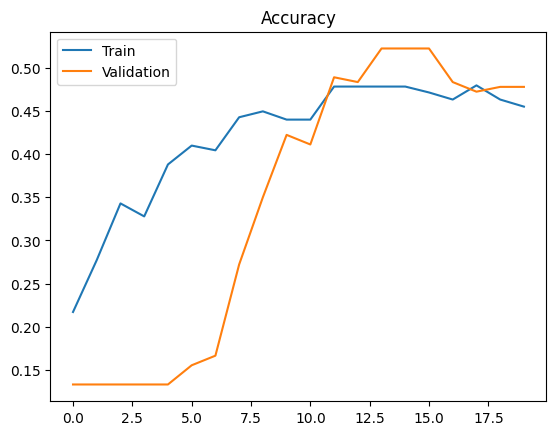

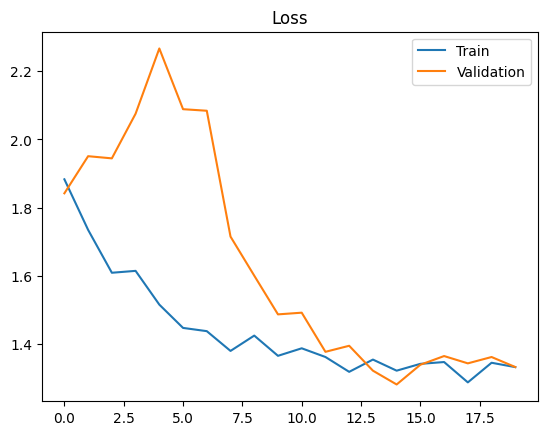

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


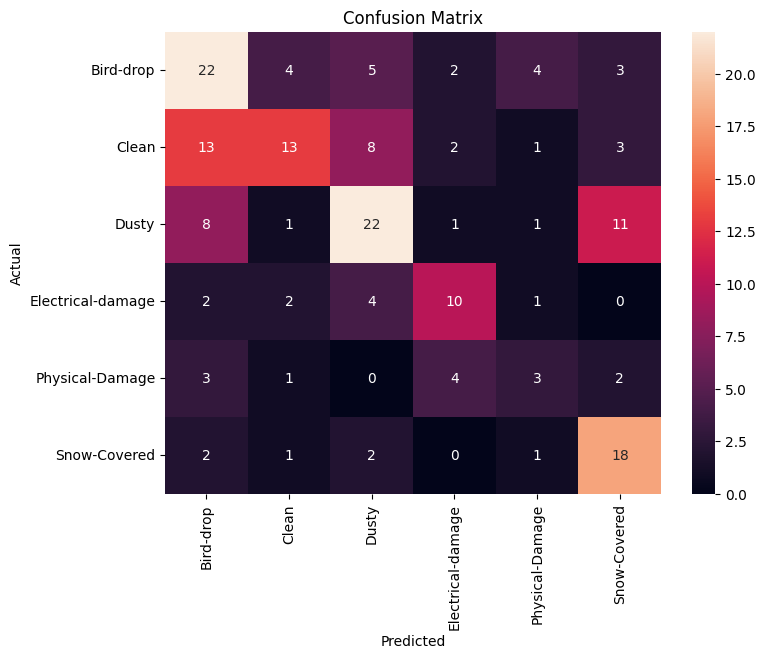

                   precision    recall  f1-score   support

        Bird-drop       0.44      0.55      0.49        40
            Clean       0.59      0.33      0.42        40
            Dusty       0.54      0.50      0.52        44
Electrical-damage       0.53      0.53      0.53        19
  Physical-Damage       0.27      0.23      0.25        13
     Snow-Covered       0.49      0.75      0.59        24

         accuracy                           0.49       180
        macro avg       0.48      0.48      0.47       180
     weighted avg       0.50      0.49      0.48       180



In [10]:
# =========================
# FULL SOLAR PANEL MODEL (FINAL FIXED)
# =========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA
# =========================
data_dir = "data/Solar panel Image"

classes = [
    "Bird-drop",
    "Clean",
    "Dusty",
    "Electrical-damage",
    "Physical-Damage",
    "Snow-Covered"
]

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

# TRAIN (shuffle=True is fine)
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes=classes,
    shuffle=True
)

# VALIDATION (🔥 IMPORTANT FIX)
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes=classes,
    shuffle=False   # ✅ VERY IMPORTANT
)

print("Classes:", train_data.class_indices)

# =========================
# CLASS WEIGHTS
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))

# =========================
# MODEL
# =========================
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers[:-50]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weights
)

# =========================
# PLOTS
# =========================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

# =========================
# CONFUSION MATRIX (FIXED)
# =========================
val_data.reset()

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=classes))

# =========================
# GRAD-CAM
# =========================
def get_gradcam(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer("conv5_block3_out").output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img

    plt.imshow(cv2.cvtColor(superimposed.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# =========================
# TEST GRAD-CAM
# =========================
# Example:
# get_gradcam("test.jpg")

Found 735 images belonging to 6 classes.
Found 181 images belonging to 6 classes.
Classes: {'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}
Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.3170 - loss: 1.7297 - val_accuracy: 0.1326 - val_loss: 2.1094 - learning_rate: 1.0000e-04
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.3905 - loss: 1.5698 - val_accuracy: 0.1326 - val_loss: 2.1038 - learning_rate: 1.0000e-04
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.4190 - loss: 1.5468 - val_accuracy: 0.1381 - val_loss: 2.0179 - learning_rate: 1.0000e-04
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.4680 - loss: 1.4504 - val_accuracy: 0.1547 - val_loss: 1.9220 - learning_rate: 1.0000e-04
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.4653 - loss: 1.4531 - val_accuracy: 0.3260 - val_loss: 1.8136 - learning_rate: 1.0000e-04
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━

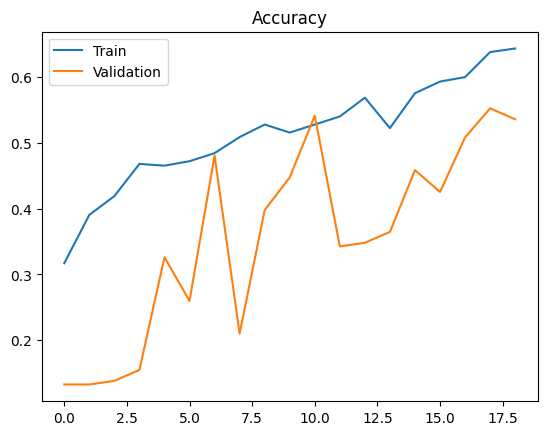

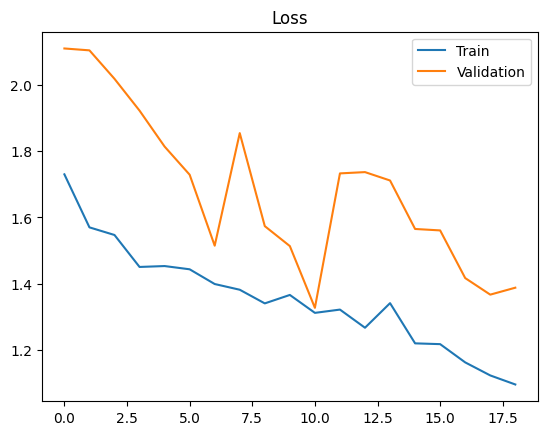

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


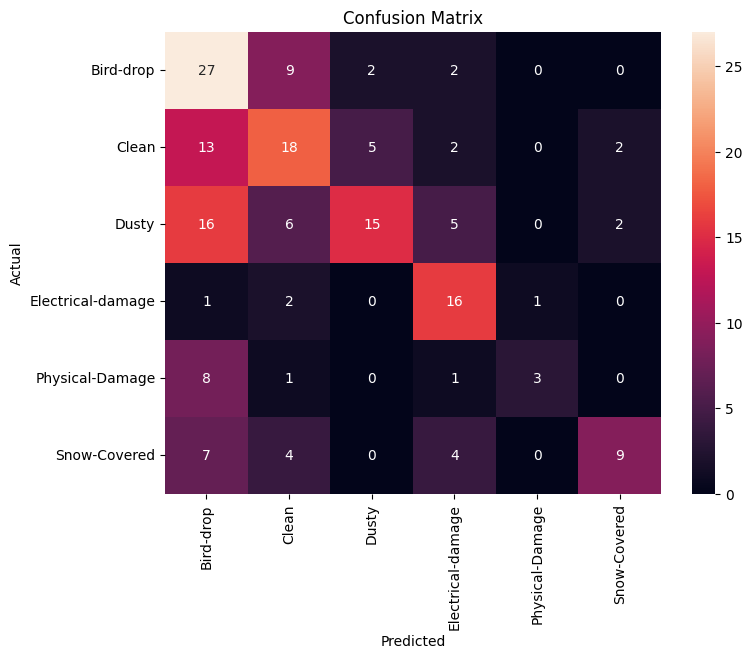

                   precision    recall  f1-score   support

        Bird-drop       0.38      0.68      0.48        40
            Clean       0.45      0.45      0.45        40
            Dusty       0.68      0.34      0.45        44
Electrical-damage       0.53      0.80      0.64        20
  Physical-Damage       0.75      0.23      0.35        13
     Snow-Covered       0.69      0.38      0.49        24

         accuracy                           0.49       181
        macro avg       0.58      0.48      0.48       181
     weighted avg       0.55      0.49      0.48       181



In [24]:
# =========================
# FINAL SOLAR PANEL MODEL (BEST STABLE VERSION)
# =========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA
# =========================
data_dir = "data/Solar panel Image"

classes = [
    "Bird-drop",
    "Clean",
    "Dusty",
    "Electrical-damage",
    "Physical-Damage",
    "Snow-Covered"
]

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes=classes,
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes=classes,
    shuffle=False   # 🔥 important
)

print("Classes:", train_data.class_indices)

# =========================
# CLASS WEIGHTS
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))

# =========================
# MODEL
# =========================
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# 🔥 Slightly more layers trainable (better than before)
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# =========================
# COMPILE (🔥 LABEL SMOOTHING)
# =========================
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=loss_fn,
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weights
)

# =========================
# PLOTS
# =========================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

# =========================
# CONFUSION MATRIX
# =========================
val_data.reset()

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=classes))

# =========================
# GRAD-CAM (SAME WORKING VERSION)
# =========================
def get_gradcam(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer("conv5_block3_out").output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img

    plt.imshow(cv2.cvtColor(superimposed.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [12]:
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
import joblib

# Load models
image_model = tf.keras.models.load_model("best_model.keras")
eff_model = joblib.load("efficiency_model.pkl")

classes = [
    "Bird-drop","Clean","Dusty",
    "Electrical-damage","Physical-Damage","Snow-Covered"
]

# Defect loss
loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

# =========================
# Grad-CAM AREA CALCULATION
# =========================
def get_defect_area(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [image_model.inputs],
        [image_model.layers[-3].output, image_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = np.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    # threshold to detect damaged region
    mask = heatmap > 0.5

    defect_area = np.sum(mask) / mask.size

    return defect_area * 100

# =========================
# MAIN FUNCTION
# =========================
def predict_full_system(
    img_path,
    temperature,
    irradiance,
    humidity,
    wind_speed,
    prev_efficiency
):
    
    # ------------------
    # 1. CLASSIFICATION
    # ------------------
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = image_model.predict(img_array)
    defect = classes[np.argmax(pred)]

    # ------------------
    # 2. DEFECT AREA
    # ------------------
    area = get_defect_area(img_path)

    # ------------------
    # 3. LOSSES
    # ------------------
    defect_loss = loss_map[defect]
    area_loss = area * 0.005

    temp_loss = max(0, (temperature - 25) * 0.004)
    irr_loss = max(0, (1000 - irradiance)/1000 * 0.1)
    humidity_loss = humidity * 0.002
    wind_loss = wind_speed * 0.001

    # ------------------
    # 4. FORMULA EFFICIENCY
    # ------------------
    total_loss = (
        defect_loss +
        area_loss +
        temp_loss +
        irr_loss +
        humidity_loss +
        wind_loss
    )

    formula_eff = 100 * (1 - total_loss)

    # ------------------
    # 5. ML MODEL
    # ------------------
    features = np.array([[
        defect_loss,
        area,
        temperature,
        irradiance,
        humidity,
        wind_speed
    ]])

    ml_eff = eff_model.predict(features)[0] * 100

    # ------------------
    # 6. FINAL OUTPUT
    # ------------------
    final_eff = (formula_eff + ml_eff) / 2

    drop = prev_efficiency - final_eff

    return {
        "Defect Type": defect,
        "Defect Area (%)": round(area,2),
        "Formula Efficiency (%)": round(formula_eff,2),
        "ML Efficiency (%)": round(ml_eff,2),
        "Final Efficiency (%)": round(final_eff,2),
        "Efficiency Drop (%)": round(drop,2),
        "Yesterday Efficiency (%)": prev_efficiency,
        "Today Efficiency (%)": round(final_eff,2)
    }

In [16]:
print(df.columns)


Index(['Date', 'Detected_Anomaly', 'Anomaly_Severity_Level', 'Affected_Area_%',
       'Efficiency_%', 'Best_Efficiency_%', 'Solar_Irradiance_W_m2',
       'Ambient_Temperature_C', 'Panel_Temperature_C', 'Humidity_%',
       'Wind_Speed_mps', 'Rainfall_mm', 'Voltage_V', 'Current_A',
       'Energy_Generated_kWh', 'Panel_Type', 'Season'],
      dtype='object')


In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import joblib

# =========================
# LOAD DATA
# =========================
df = pd.read_excel("data/Solar_Panel_5000_Days_Advanced_Dataset.xlsx")

print("Columns:", df.columns)

# =========================
# DEFECT LOSS MAP
# =========================
loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

# =========================
# CREATE FEATURES
# =========================

# Defect loss
df["defect_loss"] = df["Detected_Anomaly"].map(loss_map)

# Area (already exists)
df["defect_area"] = df["Affected_Area_%"]

# Rename for simplicity
df["temperature"] = df["Ambient_Temperature_C"]
df["irradiance"] = df["Solar_Irradiance_W_m2"]
df["humidity"] = df["Humidity_%"]
df["wind_speed"] = df["Wind_Speed_mps"]

# =========================
# SELECT FEATURES
# =========================
X = df[[
    "defect_loss",
    "defect_area",
    "temperature",
    "irradiance",
    "humidity",
    "wind_speed"
]]

# Target
y = df["Efficiency_%"]

# =========================
# TRAIN MODEL
# =========================
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# =========================
# SAVE MODEL
# =========================
joblib.dump(model, "efficiency_model.pkl")

print("✅ Efficiency model trained successfully!")

Columns: Index(['Date', 'Detected_Anomaly', 'Anomaly_Severity_Level', 'Affected_Area_%',
       'Efficiency_%', 'Best_Efficiency_%', 'Solar_Irradiance_W_m2',
       'Ambient_Temperature_C', 'Panel_Temperature_C', 'Humidity_%',
       'Wind_Speed_mps', 'Rainfall_mm', 'Voltage_V', 'Current_A',
       'Energy_Generated_kWh', 'Panel_Type', 'Season'],
      dtype='object')
✅ Efficiency model trained successfully!


Loading models...
Efficiency model loaded
Model expects features: 6

Processing: data/Solar panel Image/Electrical-damage/Electrical (12).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Prediction Probabilities:
Bird-drop: 0.0413
Clean: 0.0528
Dusty: 0.0462
Electrical-damage: 0.8154
Physical-Damage: 0.0393
Snow-Covered: 0.0049

Predicted Defect: Electrical-damage


C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_6']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


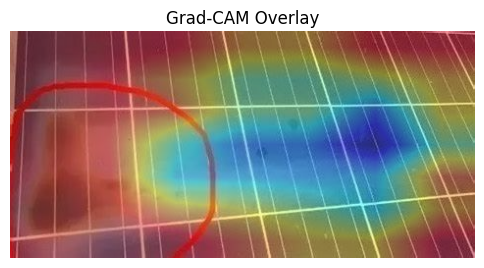


===== SOLAR PANEL REPORT =====

Defect Type: Electrical-damage
Defect Area (%): 40.82

--- Environmental Conditions ---
Temperature: 30°C
Irradiance: 900 W/m²
Humidity: 60%
Wind Speed: 5 m/s

--- Efficiency Analysis ---
Formula Efficiency (%): 24.09
ML Efficiency (%): 59.65
Final Efficiency (%): 41.87

--- Comparison ---
Yesterday Efficiency (%): 80
Today Efficiency (%): 41.87
Efficiency Drop (%): 38.13


In [26]:
# =========================
# FINAL SOLAR PANEL SYSTEM (FINAL VERSION)
# =========================

import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
IMG_PATH = "data/Solar panel Image/Electrical-damage/Electrical (12).jpg"
SHOW_HEATMAP = True   # 🔥 toggle visualization

# =========================
# CHECK FILE
# =========================
if not os.path.exists(IMG_PATH):
    raise FileNotFoundError(f"Image not found: {IMG_PATH}")

# =========================
# LOAD MODELS
# =========================
print("Loading models...")

image_model = tf.keras.models.load_model("best_model.keras")

eff_model = None
if os.path.exists("efficiency_model.pkl"):
    eff_model = joblib.load("efficiency_model.pkl")
    print("Efficiency model loaded")
    print("Model expects features:", eff_model.n_features_in_)
else:
    print("⚠️ No efficiency model found")

# =========================
# CLASS INFO
# =========================
classes = [
    "Bird-drop","Clean","Dusty",
    "Electrical-damage","Physical-Damage","Snow-Covered"
]

loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

# =========================
# INPUT PARAMETERS
# =========================
temperature = 30
irradiance = 900
humidity = 60
wind_speed = 5
prev_efficiency = 80

# =========================
# GRAD-CAM (FIXED)
# =========================
def get_defect_area(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [image_model.inputs],
        [image_model.get_layer("conv5_block3_out").output, image_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = np.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # 🔥 dynamic threshold
    threshold = np.mean(heatmap)
    mask = heatmap > threshold
    area = np.sum(mask) / mask.size

    # 🔥 overlay visualization (IMPORTANT FOR DEMO)
    if SHOW_HEATMAP:
        original = cv2.imread(img_path)
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

        heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

        plt.figure(figsize=(6,5))
        plt.imshow(overlay)
        plt.title("Grad-CAM Overlay")
        plt.axis('off')
        plt.show()

    return area * 100

# =========================
# MAIN FUNCTION
# =========================
def run_system(img_path):

    print("\nProcessing:", img_path)

    # -------- IMAGE --------
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = image_model.predict(img_array)

    print("\nPrediction Probabilities:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {pred[0][i]:.4f}")

    defect = classes[np.argmax(pred)]
    print("\nPredicted Defect:", defect)

    # -------- AREA --------
    area = get_defect_area(img_path)

    # -------- LOSSES --------
    defect_loss = loss_map[defect]
    area_loss = area * 0.005

    temp_loss = max(0, (temperature - 25) * 0.004)
    irr_loss = max(0, (1000 - irradiance)/1000 * 0.1)
    humidity_loss = humidity * 0.002
    wind_loss = wind_speed * 0.001

    total_loss = defect_loss + area_loss + temp_loss + irr_loss + humidity_loss + wind_loss

    formula_eff = 100 * (1 - total_loss)
    formula_eff = max(0, min(formula_eff, 100))

    # -------- ML --------
    if eff_model:
        features = pd.DataFrame([{
            "defect_loss": defect_loss,
            "defect_area": area,
            "temperature": temperature,
            "irradiance": irradiance,
            "humidity": humidity,
            "wind_speed": wind_speed
        }])

        ml_eff = eff_model.predict(features)[0]
        ml_eff = max(0, min(ml_eff, 100))

        final_eff = (formula_eff + ml_eff) / 2
    else:
        ml_eff = "N/A"
        final_eff = formula_eff

    drop = prev_efficiency - final_eff

    # =========================
    # OUTPUT
    # =========================
    print("\n===== SOLAR PANEL REPORT =====\n")

    print(f"Defect Type: {defect}")
    print(f"Defect Area (%): {area:.2f}")

    print("\n--- Environmental Conditions ---")
    print(f"Temperature: {temperature}°C")
    print(f"Irradiance: {irradiance} W/m²")
    print(f"Humidity: {humidity}%")
    print(f"Wind Speed: {wind_speed} m/s")

    print("\n--- Efficiency Analysis ---")
    print(f"Formula Efficiency (%): {formula_eff:.2f}")
    print(f"ML Efficiency (%): {ml_eff:.2f}")
    print(f"Final Efficiency (%): {final_eff:.2f}")

    print("\n--- Comparison ---")
    print(f"Yesterday Efficiency (%): {prev_efficiency}")
    print(f"Today Efficiency (%): {final_eff:.2f}")
    print(f"Efficiency Drop (%): {drop:.2f}")

# =========================
# RUN
# =========================
run_system(IMG_PATH)

Loading models...
Efficiency model loaded
Model expects features: 6

Processing: data/Solar panel Image/Electrical-damage/Electrical (12).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Prediction Probabilities:
Bird-drop: 0.0413
Clean: 0.0528
Dusty: 0.0462
Electrical-damage: 0.8154
Physical-Damage: 0.0393
Snow-Covered: 0.0049

Predicted Defect: Electrical-damage


C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_6']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


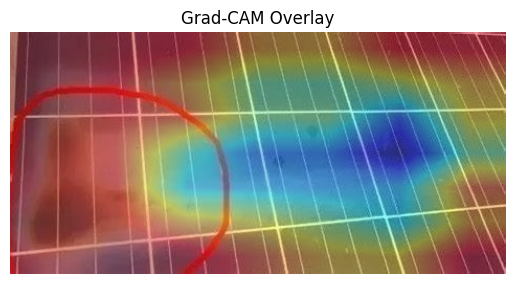


===== SOLAR PANEL REPORT =====

Defect Type: Electrical-damage
Severity Level: High
Defect Area (%): 40.82

--- Analysis ---
Reason: Electrical faults reduce energy conversion efficiency.

--- Environmental Conditions ---
Temperature: 30°C
Irradiance: 900 W/m²
Humidity: 60%
Wind Speed: 5 m/s

--- Loss Breakdown ---
Defect Loss: 0.40
Area Loss: 0.20
Temperature Loss: 0.02
Irradiance Loss: 0.01

--- Efficiency ---
Formula Efficiency (%): 24.09
ML Efficiency (%): 59.65
Final Efficiency (%): 41.87

--- Comparison ---
Yesterday Efficiency (%): 80
Today Efficiency (%): 41.87
Efficiency Drop (%): 38.13


In [27]:
# =========================
# FINAL SOLAR PANEL SYSTEM (ULTIMATE VERSION)
# =========================

import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
IMG_PATH = "data/Solar panel Image/Electrical-damage/Electrical (12).jpg"
SHOW_HEATMAP = True

# =========================
# CHECK FILE
# =========================
if not os.path.exists(IMG_PATH):
    raise FileNotFoundError(f"Image not found: {IMG_PATH}")

# =========================
# LOAD MODELS
# =========================
print("Loading models...")

image_model = tf.keras.models.load_model("best_model.keras")

eff_model = None
if os.path.exists("efficiency_model.pkl"):
    eff_model = joblib.load("efficiency_model.pkl")
    print("Efficiency model loaded")
    print("Model expects features:", eff_model.n_features_in_)
else:
    print("⚠️ No efficiency model found")

# =========================
# CLASSES + MAPS
# =========================
classes = [
    "Bird-drop","Clean","Dusty",
    "Electrical-damage","Physical-Damage","Snow-Covered"
]

loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

explanation_map = {
    "Clean": "No defect detected. Panel operating normally.",
    "Dusty": "Dust accumulation reduces sunlight absorption.",
    "Bird-drop": "Bird droppings block panel surface.",
    "Electrical-damage": "Electrical faults reduce energy conversion efficiency.",
    "Physical-Damage": "Structural damage affects panel performance.",
    "Snow-Covered": "Snow blocks sunlight completely."
}

# =========================
# INPUT PARAMETERS
# =========================
temperature = 30
irradiance = 900
humidity = 60
wind_speed = 5
prev_efficiency = 80

# =========================
# GRAD-CAM FUNCTION
# =========================
def get_defect_area(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [image_model.inputs],
        [image_model.get_layer("conv5_block3_out").output, image_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = np.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # Dynamic threshold
    threshold = np.mean(heatmap)
    mask = heatmap > threshold
    area = np.sum(mask) / mask.size

    # Visualization
    if SHOW_HEATMAP:
        original = cv2.imread(img_path)
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

        heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

        plt.imshow(overlay)
        plt.title("Grad-CAM Overlay")
        plt.axis('off')
        plt.show()

    return area * 100

# =========================
# MAIN FUNCTION
# =========================
def run_system(img_path):

    print("\nProcessing:", img_path)

    # IMAGE
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = image_model.predict(img_array)

    print("\nPrediction Probabilities:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {pred[0][i]:.4f}")

    defect = classes[np.argmax(pred)]

    print("\nPredicted Defect:", defect)

    # AREA
    area = get_defect_area(img_path)

    # SEVERITY
    if area < 10:
        severity = "Low"
    elif area < 30:
        severity = "Medium"
    else:
        severity = "High"

    # LOSSES
    defect_loss = loss_map[defect]
    area_loss = area * 0.005

    temp_loss = max(0, (temperature - 25) * 0.004)
    irr_loss = max(0, (1000 - irradiance)/1000 * 0.1)
    humidity_loss = humidity * 0.002
    wind_loss = wind_speed * 0.001

    total_loss = defect_loss + area_loss + temp_loss + irr_loss + humidity_loss + wind_loss

    formula_eff = 100 * (1 - total_loss)
    formula_eff = max(0, min(formula_eff, 100))

    # ML
    if eff_model:
        features = pd.DataFrame([{
            "defect_loss": defect_loss,
            "defect_area": area,
            "temperature": temperature,
            "irradiance": irradiance,
            "humidity": humidity,
            "wind_speed": wind_speed
        }])

        ml_eff = eff_model.predict(features)[0]
        ml_eff = max(0, min(ml_eff, 100))

        final_eff = (formula_eff + ml_eff) / 2
    else:
        ml_eff = "N/A"
        final_eff = formula_eff

    drop = prev_efficiency - final_eff

    # =========================
    # FINAL OUTPUT
    # =========================
    print("\n===== SOLAR PANEL REPORT =====\n")

    print(f"Defect Type: {defect}")
    print(f"Severity Level: {severity}")
    print(f"Defect Area (%): {area:.2f}")

    print("\n--- Analysis ---")
    print("Reason:", explanation_map[defect])

    print("\n--- Environmental Conditions ---")
    print(f"Temperature: {temperature}°C")
    print(f"Irradiance: {irradiance} W/m²")
    print(f"Humidity: {humidity}%")
    print(f"Wind Speed: {wind_speed} m/s")

    print("\n--- Loss Breakdown ---")
    print(f"Defect Loss: {defect_loss:.2f}")
    print(f"Area Loss: {area_loss:.2f}")
    print(f"Temperature Loss: {temp_loss:.2f}")
    print(f"Irradiance Loss: {irr_loss:.2f}")

    print("\n--- Efficiency ---")
    print(f"Formula Efficiency (%): {formula_eff:.2f}")
    print(f"ML Efficiency (%): {ml_eff:.2f}")
    print(f"Final Efficiency (%): {final_eff:.2f}")

    print("\n--- Comparison ---")
    print(f"Yesterday Efficiency (%): {prev_efficiency}")
    print(f"Today Efficiency (%): {final_eff:.2f}")
    print(f"Efficiency Drop (%): {drop:.2f}")

# =========================
# RUN
# =========================
run_system(IMG_PATH)